## Asymmetric Notch Filter and its application to complex IQ signals

In [1]:
import numpy as np
from scipy import signal
import scipy.fft as spfft
from numpy.polynomial.polynomial import polyval
import matplotlib.pyplot as plt

In [2]:
# Interactive plotting.  Comment out this next line if inline plots are desired.
%matplotlib qt

In [3]:
# Function to create IQ representation of sine wave at a given freq for a given sample rate.
#
# Inputs: 
#  freq - frequency of sine wave, Hz
#  amp  - amplitude, arbitrary units
#  fs   - sampling rate of sine wave, Hz
#  no_samps - number of samples to generate
#
# Returns:
#  complex (IQ) representation of sine wave with input parameters.
#
# Affects: None
#
# Exceptions: AssertionError if freq >= fs.
#
def create_sig(freq, amp, fs, no_samps):
    assert freq < fs
    delta_t = 1.0 / fs
    x = np.linspace(0.0, no_samps * delta_t, no_samps, endpoint=False)
    iq = amp * np.exp(1j * freq * 2.0 * np.pi * x)
    return iq

In [4]:
# Function to plot the frequency domain spectrum of a complex signal.
#
# Inputs: 
#  y - complex time domain signal to be plotted
#  fs - sampling rate, Hz
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)
#  ylim - y axis plot limits: (min, max)
#
# Returns:
#  Plot of frequency domain representation of signal.
#
# Affects: None
#
# Exceptions: None
#
def spec_plot(y, fs, ttext, xlim, ylim):
    delta_t = 1.0 / fs
    no_samps = len(y)
    yf = spfft.fft(y)
    xf = spfft.fftfreq(no_samps, delta_t)
    xf_shift = spfft.fftshift(xf)
    yf_shift = spfft.fftshift(yf)
    plt.figure()
    plt.plot(xf_shift, 1.0/no_samps * np.abs(yf_shift))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Spectral amplitude')
    plt.title(ttext)
    plt.grid()
    plt.show()

In [5]:
# Function to plot the frequency domain response of a filter.
#
# Inputs: 
#  w - array of frequencies at which filter response h was computed.
#  H - array of frequency response, as complex numbers.
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)
#  ylim - y axis plot limits: (min, max)
#
# Returns:
#  Plot of abs(filter response) vs. real frequency.
#
# Affects: None
#
# Exceptions: None
#
def plot_filt(w, H, ttext, xlim, ylim):
    plt.figure()
    plt.plot(np.real(w), np.abs(H))
    plt.ylim(ylim)
    plt.xlim(xlim)
    plt.xlabel("Frequency, Hz")
    plt.ylabel("Magnitude")
    plt.title(ttext)
    plt.grid()
    plt.show()

In [6]:
# Function to design a linear infinite impulse response (IIR) notch filter using pole-zero placement.
#
# Inputs: 
#  notch_freq - Frequency of notch in Hz
#  sample_rate - Sampling rate of filter, Hz
#  q_factor - Quality factor of the notch.  Smaller q_factor = wider notch.
#
# Returns:
#  (b, a, zi) where
#  b - Filter numerator coefficients
#  a - Filter denominator coefficients
#  zi - Array with initial filter state vector
#      (used with "lfilter" command when performing time-domain filtering)
#
# Affects: None
#
# Exceptions: None
#
def notch_fil(notch_freq, sample_rate, q_factor):
        
    # First normalize the notch frequency to (-1.0 to 1.0)
    w0 = notch_freq / sample_rate
    
    # Place a zero at notch frequency (on unit circle)
    zero = np.exp(2j * np.pi * w0)
    
    # Place a pole at same angle, but inside unit circle
    # Pole radius is controlled by Q factor and sets the notch width
    r = 1 - (1 / (2 * q_factor))  # Pole radius
    pole = r * np.exp(2j * np.pi * w0)
    
    # Convert zero and pole to filter transfer function coefficients using the expression
    # H(z) = (z - zero) / (z - pole)
    # where z = normalized frequency
    b = np.array([1, -zero])
    a = np.array([1, -pole])
    
    # Normalize response for unity gain at DC by adjusting numerator coefficients
    dc_gain = np.sum(b) / np.sum(a)
    b = b / dc_gain
    
    # Construct initial conditions for step response steady-state.
    zi = signal.lfilter_zi(b, a)
    
    # Filter is complete
    return b, a, zi

In [7]:
# Function to calculate filter frequency response of a FIR or IIR filter.
#  Note: this is for visualization purposes only - the time domain "b" and "a" coefficients
#   do the work here for the actual filtering further down, through the "lfilter" operator.
#
# Inputs: 
#  b - numerator coefficients of filter
#  a  - denominator coefficients of filter
#  sample_rate   - Sampling rate of filter, Hz
#  
# Returns:
#  freqs - Frequencies at which filter response was computed, Hz
#      range: [-sample_rate/2, +sample_rate/2)
#  H - Filter frequency response, as complex numbers
#
# Affects: None
#
def comp_fil_response(b, a, sample_rate):
    
    # Directly compute filter response.
    #
    # For more background on why the frequencies are first computed as radians on (-pi, pi] range, 
    # consult a DSP textbook for an explanation of z-transforms - e.g.
    #    Oppenheim & Schafer, Discrete-Time Signal Processing (3rd ed.)
    #    Proakis & Manolakis, Digital Signal Processing: Principles, Algorithms, and Applications
    #    Lyons, Understanding Digital Signal Processing
    #
    
    # Reverse the coefficients due to library incompatibilities:
    #
    # At present, "polyval" requires ordering of numerator and denominator coefficients 
    # from the lowest degree (i.e. the constant term) up to the highest degree.
    # However, the filtering operator lfilter() expect the numerator and denominator 
    # in highest to lowest degree form.
    #
    # This is true for numpy version 1.22.2, the version used at the time of writing,
    #   and for scipy version 1.8.0.  It may change in the future; beware.
    #  
    b = b[::-1]
    a = a[::-1]
    
    # compute at 2048 frequencies for good fidelity
    w = np.linspace(-np.pi, np.pi, 2048, endpoint=False)
    
    # main loop
    z = np.exp(1j * w)
    num = np.zeros(len(z), dtype=np.complex64)
    den = np.zeros(len(z), dtype=np.complex64)
    for ii in range(len(z)):
        num[ii] = polyval(z[ii], b)
        den[ii] = polyval(z[ii], a)
    H = num / den

    # convert frequencies to Hz rather than radians
    freqs = w * sample_rate / (2 * np.pi) # convert from radians to freq

    return freqs, H

In [8]:
fs = 32000       # sample rate
no_samps = 32000 # number of samples
cf = 10000       # center frequenccy

In [9]:
# 4 signal frequencies with different amplitudes
sig_1_f = 8000
sig_1_a = 0.7
sig_2_f = 9000
sig_2_a = 0.8
sig_3_f = 11000
sig_3_a = 0.9
sig_4_f = 12000
sig_4_a = 1.0

In [10]:
# shift frequencies from center frequency to baseband
b_sig_1_f = 8000 - cf
b_sig_1_a = 0.7
b_sig_2_f = 9000 - cf
b_sig_2_a = 0.8
b_sig_3_f = 11000 - cf
b_sig_3_a = 0.9
b_sig_4_f = 12000 - cf
b_sig_4_a = 1.0

In [11]:
# create signals individually
b_sig_1 = create_sig(b_sig_1_f, sig_1_a, fs, no_samps)
b_sig_2 = create_sig(b_sig_2_f, sig_2_a, fs, no_samps)
b_sig_3 = create_sig(b_sig_3_f, sig_3_a, fs, no_samps)
b_sig_4 = create_sig(b_sig_4_f, sig_4_a, fs, no_samps)
# sum them to create input complex signal
b_sig = b_sig_1 + b_sig_2 + b_sig_3 + b_sig_4

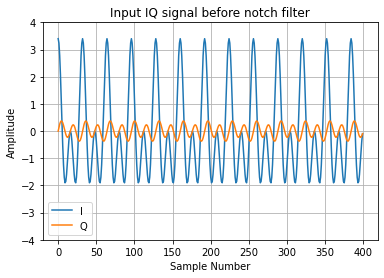

In [12]:
# plot time series before filter
plt.figure()
plt.plot(np.real(b_sig[0:400]),label='I')
plt.plot(np.imag(b_sig[0:400]),label='Q')
plt.ylim(-4,4)  # consistent Y axis for later plots after filter
plt.grid()
plt.legend()
plt.title('Input IQ signal before notch filter')
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

In [13]:
# Frequency plot limits will be the same for all plots following this point
ylim = (0, 1.05)
xlim = (-3000, 3000)

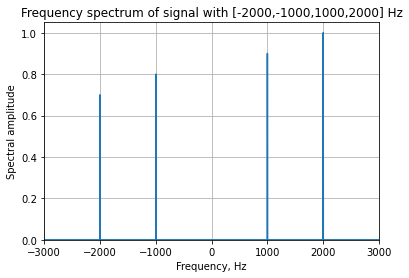

In [14]:
# plot spectrum of four baseband signals
spec_plot(b_sig, fs, 
          'Frequency spectrum of signal with [%.0f,%.0f,%.0f,%.0f] Hz' % (b_sig_1_f, b_sig_2_f, b_sig_3_f, b_sig_4_f), 
          xlim, ylim)

In [15]:
# compute the coefficients of a notch filter
# with center at -1 kHz and with quality factor 30 (sets shape)
b, a, zi = notch_fil(-1000, fs, 30)

In [16]:
# compute filter frequency response
freqs, H = comp_fil_response(b, a, fs)

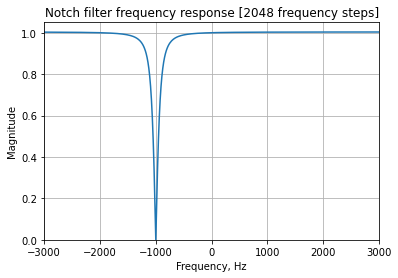

In [17]:
# plot frequency domain filter response
plot_filt(freqs, H, 
          'Notch filter frequency response [%i frequency steps]' % (len(freqs)), 
          xlim, ylim)

In [18]:
print('Filter response coefficients in time domain:')
print('Numerator: ' + str(b))
print('Denominator: ' + str(a))

Filter response coefficients in time domain:
Numerator: [ 0.99166667-0.08460975j -0.95610553+0.27644857j]
Denominator: [ 1.        +0.j         -0.96443886+0.19183882j]


In [19]:
# apply time-domain filter to complex input signal with initial filter state vector
#   NB: zi_out gives output filter state vector in cases where more data following this would be
#   filtered (not used here)
filtered, zi_out = signal.lfilter(b, a, b_sig, zi=zi)

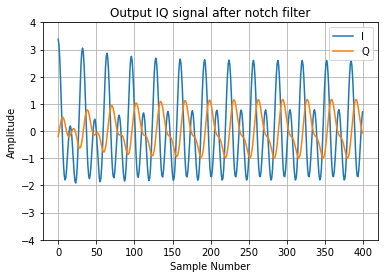

In [20]:
# plot the time series of the output filtered data
plt.figure()
plt.plot(np.real(filtered[0:400]),label='I')
plt.plot(np.imag(filtered[0:400]),label='Q')
plt.ylim(-4,4)  # consistent Y axis for comparing with earlier plot
plt.grid()
plt.legend()
plt.title('Output IQ signal after notch filter')
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.show()

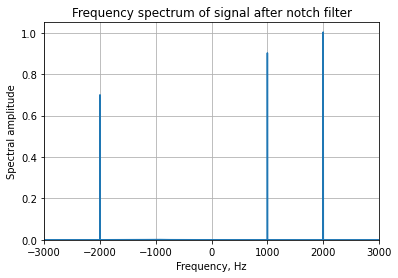

In [21]:
# plot the spectrum after the filter has been applied
spec_plot(filtered, fs, 
          'Frequency spectrum of signal after notch filter',
          xlim, ylim)